# Analyse de réseaux avec Python (NetworkX)

Ce notebook propose une introduction pratique à l'analyse de réseaux (*network analysis*) avec Python. Vous apprendrez à :
- Découvrir la bibliothèque NetworkX et sa documentation
- Créer un réseau à la main (nœuds, liens, attributs)
- Visualiser un réseau avec matplotlib
- Calculer des indicateurs de réseau : centralité de degré, centralité d'intermédiarité, coefficient de clustering
- Charger un réseau réel au format GEXF depuis une URL
- Interpréter ces indicateurs sur un cas d'étude issu de la recherche historique : le registre des douanes de 1445 (Japon médiéval)

---
# Partie 1 : Découvrir NetworkX

## 1.1 Installation et documentation

**NetworkX** est la bibliothèque de référence en Python pour créer, manipuler et étudier des réseaux (aussi appelés graphes). Elle est très utilisée en sciences humaines et sociales pour l'analyse de réseaux sociaux, de correspondances, de citations ou d'échanges commerciaux.

Documentation officielle : https://networkx.org/documentation/stable/

In [ ]:
%pip install networkx

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\Eric Mermet\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [ ]:
import networkx as nx

print(f"Version de NetworkX installée : {nx.__version__}")

Version de NetworkX installée : 3.6.1


## 1.2 Créer un réseau : nœuds et liens

Un réseau (ou graphe) est composé de **nœuds** (*nodes*, les entités : personnes, lieux, institutions...) reliés par des **liens** (*edges*, les relations entre ces entités).

NetworkX propose plusieurs types de graphes :
- `nx.Graph()` : réseau **non orienté** (une relation symétrique, ex. "connaît")
- `nx.DiGraph()` : réseau **orienté** (une relation à sens unique, ex. "envoie une lettre à")
- `nx.MultiGraph()` / `nx.MultiDiGraph()` : autorisent plusieurs liens entre les deux mêmes nœuds

In [3]:
# Création d'un réseau non orienté
G = nx.Graph()

# Ajouter des nœuds un par un ou en liste
G.add_node("Diplomate A")
G.add_nodes_from(["Diplomate B", "Diplomate C"])

# Ajouter des liens un par un ou en liste
G.add_edge("Diplomate A", "Diplomate B")
G.add_edges_from([("Diplomate A", "Diplomate C"), ("Diplomate B", "Diplomate C")])

print("Nœuds :", list(G.nodes()))
print("Liens :", list(G.edges()))
print(f"\nNombre de nœuds : {G.number_of_nodes()}")
print(f"Nombre de liens : {G.number_of_edges()}")

Nœuds : ['Diplomate A', 'Diplomate B', 'Diplomate C']
Liens : [('Diplomate A', 'Diplomate B'), ('Diplomate A', 'Diplomate C'), ('Diplomate B', 'Diplomate C')]

Nombre de nœuds : 3
Nombre de liens : 3


## 1.3 Attributs et vocabulaire de base

Nœuds et liens peuvent porter des **attributs** (rôle, date, poids...). Quelques notions essentielles :
- le **degré** d'un nœud : son nombre de liens
- les **voisins** (*neighbors*) d'un nœud : les nœuds directement reliés à lui
- le **poids** (*weight*) d'un lien : par exemple un nombre d'échanges

In [4]:
# Ajouter des attributs à un nœud et à un lien
G.nodes["Diplomate A"]["role"] = "Ambassadeur"
G.edges["Diplomate A", "Diplomate B"]["type"] = "correspondance"

print("Attributs de 'Diplomate A' :", G.nodes["Diplomate A"])
print("Attributs du lien A-B :", G.edges["Diplomate A", "Diplomate B"])

print("\nDegré de chaque nœud :", dict(G.degree()))
print("Voisins de 'Diplomate A' :", list(G.neighbors("Diplomate A")))

Attributs de 'Diplomate A' : {'role': 'Ambassadeur'}
Attributs du lien A-B : {'type': 'correspondance'}

Degré de chaque nœud : {'Diplomate A': 2, 'Diplomate B': 2, 'Diplomate C': 2}
Voisins de 'Diplomate A' : ['Diplomate B', 'Diplomate C']


---
# Partie 2 : Créer, visualiser et analyser un réseau fictif

## 2.1 Un réseau commercial fictif

Construisons un petit réseau fictif de marchands reliés par des transactions, pour préparer le terrain avant d'étudier un cas réel en partie 3.

In [5]:
marchands = nx.Graph()

# (marchand_1, marchand_2, nombre_de_transactions)
liens = [
    ("Aldric", "Beatriz", 3),
    ("Aldric", "Cassian", 1),
    ("Beatriz", "Cassian", 2),
    ("Beatriz", "Dorotea", 4),
    ("Cassian", "Dorotea", 1),
    ("Dorotea", "Elouan", 5),
    ("Elouan", "Farida", 2),
    ("Dorotea", "Farida", 1),
    ("Farida", "Gwenn", 3),
]

for marchand_1, marchand_2, nb_transactions in liens:
    marchands.add_edge(marchand_1, marchand_2, weight=nb_transactions)

print(f"{marchands.number_of_nodes()} marchands, {marchands.number_of_edges()} relations commerciales")

7 marchands, 9 relations commerciales


## 2.2 Visualiser le réseau

`matplotlib` permet de dessiner directement un graphe NetworkX avec `nx.draw()`. On utilise un algorithme de placement (*layout*) comme `spring_layout` pour disposer les nœuds de façon lisible.

In [6]:
%pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\Eric Mermet\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


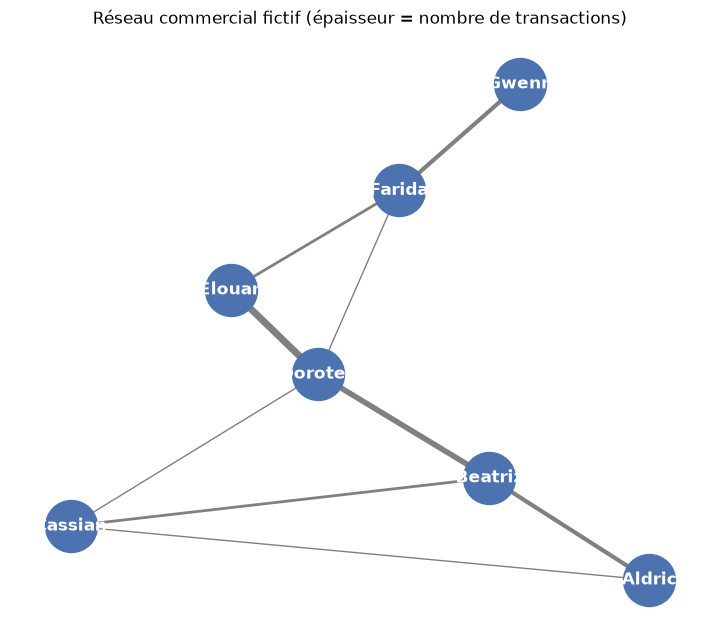

In [7]:
import matplotlib.pyplot as plt

pos = nx.spring_layout(marchands, seed=42)
epaisseurs = [marchands[u][v]["weight"] for u, v in marchands.edges()]

plt.figure(figsize=(7, 6))
nx.draw(
    marchands, pos, with_labels=True,
    node_color="#4C72B0", node_size=1400,
    font_color="white", font_weight="bold",
    width=epaisseurs, edge_color="gray"
)
plt.title("Réseau commercial fictif (épaisseur = nombre de transactions)")
plt.show()

## 2.3 Centralité de degré

La **centralité de degré** (*degree centrality*) mesure simplement combien de liens directs possède chaque nœud, normalisé par le nombre maximum de liens possibles. Elle répond à la question : *qui est le plus connecté ?*

In [8]:
degre = nx.degree_centrality(marchands)

print("Centralité de degré :")
for marchand, valeur in sorted(degre.items(), key=lambda x: x[1], reverse=True):
    print(f"  {marchand:10s} : {valeur:.2f}")

Centralité de degré :
  Dorotea    : 0.67
  Beatriz    : 0.50
  Cassian    : 0.50
  Farida     : 0.50
  Aldric     : 0.33
  Elouan     : 0.33
  Gwenn      : 0.17


## 2.4 Centralité d'intermédiarité (betweenness)

La **centralité d'intermédiarité** (*betweenness centrality*) mesure à quel point un nœud sert de passage obligé sur les plus courts chemins entre les autres nœuds. Elle répond à la question : *qui est le "pont" ou l'intermédiaire stratégique du réseau ?*

Un nœud peut avoir un degré modeste mais une intermédiarité très forte s'il relie deux groupes qui, sans lui, seraient déconnectés.

In [9]:
intermediarite = nx.betweenness_centrality(marchands)

print("Centralité d'intermédiarité :")
for marchand, valeur in sorted(intermediarite.items(), key=lambda x: x[1], reverse=True):
    print(f"  {marchand:10s} : {valeur:.2f}")

Centralité d'intermédiarité :
  Dorotea    : 0.60
  Farida     : 0.33
  Beatriz    : 0.13
  Cassian    : 0.13
  Aldric     : 0.00
  Elouan     : 0.00
  Gwenn      : 0.00


## 2.5 Coefficient de clustering

Le **coefficient de clustering** mesure à quel point les voisins d'un nœud sont eux-mêmes connectés entre eux (des "triangles" fermés). Il répond à la question : *ce nœud évolue-t-il dans un groupe soudé ou plutôt dispersé ?*

In [10]:
clustering = nx.clustering(marchands)

print("Coefficient de clustering :")
for marchand, valeur in sorted(clustering.items(), key=lambda x: x[1], reverse=True):
    print(f"  {marchand:10s} : {valeur:.2f}")

print(f"\nClustering moyen du réseau : {nx.average_clustering(marchands):.3f}")

Coefficient de clustering :
  Aldric     : 1.00
  Elouan     : 1.00
  Beatriz    : 0.67
  Cassian    : 0.67
  Dorotea    : 0.33
  Farida     : 0.33
  Gwenn      : 0.00

Clustering moyen du réseau : 0.571


**Exercice** : comparez les trois classements obtenus. Le marchand le plus connecté (degré) est-il aussi le plus stratégique (intermédiarité) ? Repérez un marchand avec un fort coefficient de clustering et expliquez, à partir du dessin du réseau, pourquoi ses voisins sont peu (ou beaucoup) connectés entre eux.

*Indice : "Dorotea" a le plus grand degré et la plus forte intermédiarité — elle relie deux petits groupes de marchands (Aldric/Beatriz/Cassian d'un côté, Elouan/Farida/Gwenn de l'autre). Sans elle, ces deux groupes seraient déconnectés.*

---
# Partie 3 : Un réseau historique réel — le registre des douanes de 1445

## 3.1 Présentation du cas d'étude

Le réseau que nous allons charger provient d'une recherche publiée dans le *Journal of Historical Network Research* :

> Tatoyan, D., Kobiljski, A., Yamashita, H. & Mermet, É., *Network Analysis of a Maritime Trade in Medieval Japan*, JHNR, vol. 10, n°1, 2023.
> https://jhnr.net/articles/10.25517/jhnr.v10i1.86

Cette étude s'appuie sur le **registre des douanes de Hyōgo de 1445** (*Hyōgo kitazeki irifune nōchō*), le seul registre douanier médiéval encore conservé au Japon. Il consigne, jour après jour, les navires entrant dans le port de Hyōgo, leur cargaison, ainsi que les agents commerciaux et armateurs impliqués dans chaque transaction.

Dans le réseau construit à partir de ce registre :
- les **nœuds** représentent des agents commerciaux, des armateurs, des institutions (temples, clans guerriers) ou des lieux
- les **liens** représentent les transactions et relations documentées dans le registre

Les auteurs montrent notamment qu'une partie des individus enregistrés comme simples "agents commerciaux" fonctionnaient en réalité comme de véritables **armateurs**, un rôle que l'analyse de réseau permet de révéler alors qu'il n'est pas explicite dans la source.

## 3.2 Charger le réseau depuis une URL

Le réseau est disponible au format **GEXF** (*Graph Exchange XML Format*) sur GitHub. On le télécharge avec le module `urllib.request` (l'équivalent, en Python 3, du module `urllib2` de Python 2) puis on le charge directement avec `nx.read_gexf()`, sans avoir besoin de l'enregistrer sur le disque.

In [11]:
import urllib.request

data_file_url = urllib.request.urlopen(
    "https://raw.githubusercontent.com/j-innovatech/registry1445/main/data/Export_cnrs_jinnovatech_20230322105432.gexf"
)
G = nx.read_gexf(data_file_url)

print(f"Type de réseau : {type(G).__name__}")
print(f"Nombre de nœuds : {G.number_of_nodes()}")
print(f"Nombre de liens : {G.number_of_edges()}")
print(f"Orienté : {G.is_directed()}")

Type de réseau : MultiDiGraph
Nombre de nœuds : 4742
Nombre de liens : 18950
Orienté : True


Le réseau est un **MultiDiGraph** : un graphe orienté qui autorise plusieurs liens entre les deux mêmes nœuds (par exemple, deux transactions distinctes entre les deux mêmes agents).

## 3.3 Explorer les attributs des données

Regardons à quoi ressemblent un nœud et un lien du réseau.

In [12]:
premier_noeud_id, premier_noeud_attrs = list(G.nodes(data=True))[0]
print("Identifiant :", premier_noeud_id)
print("Attributs :", premier_noeud_attrs)

print()
premier_lien = list(G.edges(data=True))[0]
print("Exemple de lien :", premier_lien)

Identifiant : 5000
Attributs : {'name': '79 Transport de Yamana Hyōbu no shō / 山名兵部少輔殿 Yamana Hyōbu no shō 山名兵部少輔 Clan guerrier Mineure', 'image': 'https://heurist.huma-num.fr/heurist/?db=cnrs_jinnovatech&icon=111', 'rectype': '111', 'count': 0.0, 'url': 'https://heurist.huma-num.fr/heurist/recID=5000&fmt=html&db=cnrs_jinnovatech', 'label': '79 Transport de Yamana Hyōbu no shō / 山名兵部少輔殿 Yamana Hyōbu no shō 山名兵部少輔 Clan guerrier Mineure'}

Exemple de lien : ('5000', '11196', {'relation-id': 1237.0, 'relation-name': 'Nom institution', 'relation-count': 1.0, 'id': '1', 'weight': 1.0})


Ce fichier a été exporté depuis une base [Heurist](https://heurist.huma-num.fr/) : le champ `label` regroupe en une seule chaîne de texte plusieurs informations (numéro de transaction, description en français et en japonais, nom de l'agent, catégorie...), séparées à l'origine par des retours à la ligne. C'est un très bon exemple de donnée historique "brute" qu'il faut explorer avant de l'analyser.

## 3.4 Nettoyer les données avant de calculer des indicateurs

Ne faisons jamais confiance aveuglément à un indicateur de centralité : regardons toujours ce que représentent concrètement les nœuds en tête de classement.

In [13]:
degre_brut = nx.degree_centrality(G)

print("Top 5 des nœuds par centralité de degré (données brutes) :")
for id_noeud, valeur in sorted(degre_brut.items(), key=lambda x: x[1], reverse=True)[:5]:
    print(f"  {G.nodes[id_noeud]['label']!r:55s} : {valeur:.3f}")

Top 5 des nœuds par centralité de degré (données brutes) :
  '0 Aucun /  X'                                          : 0.245
  '8 Doyu /  道祐'                                          : 0.173
  'Hyōgo / 兵庫（地下）'                                        : 0.159
  'Nozaki-ke Monjo in Nippon Engyō Taikei Kinsei Shiryō T3' : 0.145
  '12 Emonkuro /  衛門九郎'                                   : 0.105


Le nœud arrivant en tête n'est pas un acteur historique : `'0 Aucun /  X'` est une valeur par défaut utilisée dans le registre pour signaler un agent **non renseigné**. Comme cette étiquette est répétée à chaque transaction sans agent identifié, ce nœud agrège artificiellement des centaines de liens et fausse le classement.

C'est un cas d'école en analyse de réseaux appliquée à des sources historiques : il faut identifier et retirer ces nœuds "fourre-tout" avant d'interpréter quoi que ce soit.

In [14]:
noeuds_a_retirer = [n for n, d in G.nodes(data=True) if d.get("label", "").startswith("0 Aucun")]
print(f"{len(noeuds_a_retirer)} nœuds 'valeur non renseignée' repérés et retirés")

G_propre = G.copy()
G_propre.remove_nodes_from(noeuds_a_retirer)

degre_propre = nx.degree_centrality(G_propre)
print("\nTop 5 des nœuds par centralité de degré (après nettoyage) :")
for id_noeud, valeur in sorted(degre_propre.items(), key=lambda x: x[1], reverse=True)[:5]:
    print(f"  {G_propre.nodes[id_noeud]['label']!r:55s} : {valeur:.3f}")

42 nœuds 'valeur non renseignée' repérés et retirés

Top 5 des nœuds par centralité de degré (après nettoyage) :
  '8 Doyu /  道祐'                                          : 0.175
  'Hyōgo / 兵庫（地下）'                                        : 0.161
  'Nozaki-ke Monjo in Nippon Engyō Taikei Kinsei Shiryō T3' : 0.146
  '12 Emonkuro /  衛門九郎'                                   : 0.106
  '30 Kiya /  木屋・木や'                                      : 0.091


Une fois ce nœud retiré, c'est **Doyu (道祐)** qui arrive en tête, suivi de **Hyōgo** elle-même (le port où est tenu le registre). C'est précisément ce type d'agent extrêmement central que les auteurs de l'article identifient comme fonctionnant en réalité comme un armateur, au-delà de son statut officiel d'agent commercial.

*Remarque pour aller plus loin : en explorant le réseau, on trouve aussi des dizaines de nœuds distincts portant exactement le même nom (ex. "Doyu" apparaît sous plus de 20 identifiants différents, la plupart isolés). Il s'agit très probablement de la même personne enregistrée séparément à chaque transaction plutôt que d'un doublon fusionné — un problème classique de **résolution d'entités** en prosopographie numérique.*

## 3.5 Centralité d'intermédiarité et clustering sur le réseau réel

Un registre douanier documente une multitude de petites transactions ponctuelles : le réseau est donc très fragmenté. Regardons son nombre de composantes connexes avant de calculer des indicateurs qui nécessitent un réseau connecté.

In [15]:
composantes = list(nx.weakly_connected_components(G_propre))
plus_grande_composante = max(composantes, key=len)

print(f"Nombre de composantes faiblement connexes : {len(composantes)}")
print(f"Taille de la plus grande composante : {len(plus_grande_composante)} nœuds")

# On travaille sur la composante principale, convertie en réseau simple non orienté
G_principal = nx.Graph(G_propre.subgraph(plus_grande_composante))
print(f"\nRéseau simplifié (non orienté) : {G_principal.number_of_nodes()} nœuds, {G_principal.number_of_edges()} liens")

Nombre de composantes faiblement connexes : 870
Taille de la plus grande composante : 3321 nœuds



Réseau simplifié (non orienté) : 3321 nœuds, 7464 liens


Sur un réseau de cette taille, `betweenness_centrality` peut prendre une bonne minute car elle explore les plus courts chemins entre toutes les paires de nœuds. Sur un réseau encore plus grand, on peut se contenter d'une **estimation approchée** en tirant un échantillon de nœuds sources avec le paramètre `k` (ex. `nx.betweenness_centrality(G, k=200, seed=42)`).

In [16]:
intermediarite = nx.betweenness_centrality(G_principal)

print("Top 5 des nœuds par centralité d'intermédiarité :")
for id_noeud, valeur in sorted(intermediarite.items(), key=lambda x: x[1], reverse=True)[:5]:
    print(f"  {G_principal.nodes[id_noeud]['label']!r:55s} : {valeur:.3f}")

Top 5 des nœuds par centralité d'intermédiarité :
  '8 Doyu /  道祐'                                          : 0.254
  'Hyōgo / 兵庫（地下）'                                        : 0.228
  '12 Emonkuro /  衛門九郎'                                   : 0.132
  '25 Jirozaburo1 /  二郎三郎'                                : 0.108
  '30 Kiya /  木屋・木や'                                      : 0.091


In [17]:
print(f"Clustering moyen (réseau réel) : {nx.average_clustering(G_principal):.4f}")
print(f"Clustering moyen (réseau fictif, partie 2) : {nx.average_clustering(marchands):.4f}")

Clustering moyen (réseau réel) : 0.0076
Clustering moyen (réseau fictif, partie 2) : 0.5714


Le clustering moyen du réseau réel est proche de zéro, très inférieur à celui du réseau fictif de la partie 2. Ce n'est pas une anomalie : un registre de transactions ressemble davantage à une structure en **étoiles** (des agents centraux reliés à de nombreux partenaires ponctuels qui, eux, ne se connaissent pas nécessairement entre eux) qu'à un réseau social où les amis d'un ami ont tendance à se connaître.

## 3.6 Visualiser le réseau réel

Dessiner les 3 000+ nœuds du réseau produirait un amas illisible (souvent appelé *hairball*). Sur un grand réseau, on préfère généralement :
1. examiner le **voisinage direct** d'un acteur central
2. regarder la **distribution des degrés** de l'ensemble du réseau

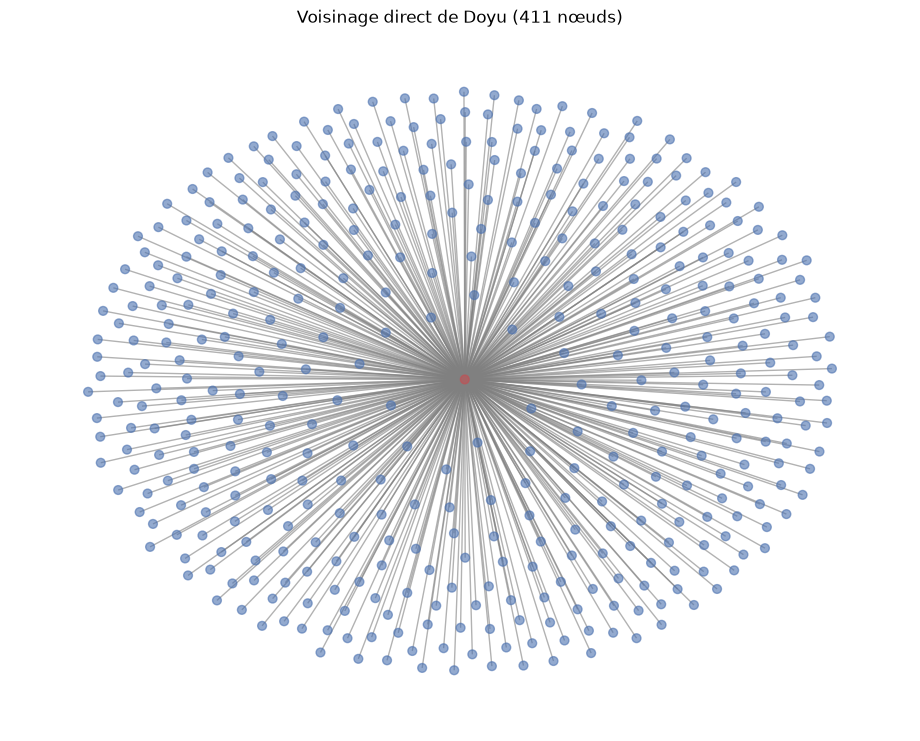

In [18]:
id_doyu = max(
    G_principal.nodes(),
    key=lambda n: G_principal.degree(n) if "Doyu" in G_principal.nodes[n].get("label", "") else -1
)
voisinage_doyu = nx.ego_graph(G_principal, id_doyu, radius=1)

plt.figure(figsize=(9, 7))
pos = nx.spring_layout(voisinage_doyu, seed=42)
couleurs = ["#C44E52" if n == id_doyu else "#4C72B0" for n in voisinage_doyu.nodes()]
nx.draw(voisinage_doyu, pos, node_size=40, node_color=couleurs, edge_color="gray", alpha=0.6, with_labels=False)
plt.title(f"Voisinage direct de Doyu ({voisinage_doyu.number_of_nodes()} nœuds)")
plt.show()

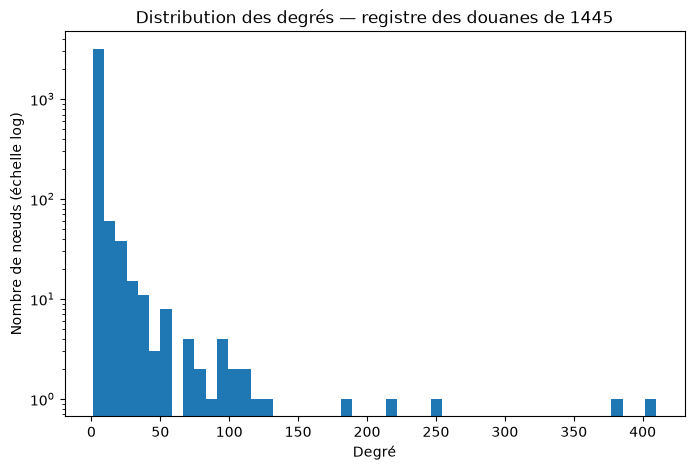

In [19]:
degres = [d for _, d in G_principal.degree()]

plt.figure(figsize=(8, 5))
plt.hist(degres, bins=50)
plt.yscale("log")
plt.xlabel("Degré")
plt.ylabel("Nombre de nœuds (échelle log)")
plt.title("Distribution des degrés — registre des douanes de 1445")
plt.show()

La très grande majorité des nœuds n'ont que quelques liens, tandis qu'une poignée de nœuds (agents-clés, institutions, le port de Hyōgo lui-même) en concentrent des centaines. Cette structure très inégalitaire — quelques hubs, une longue traîne de nœuds peu connectés — est typique des réseaux de commerce et de communication historiques, et c'est précisément ce que l'analyse de centralité permet de mettre en évidence, au-delà de ce que dit explicitement la source.

---
# Résumé

Dans ce notebook, nous avons appris à :

1. **Découvrir NetworkX** : création de graphes orientés/non orientés, nœuds, liens, attributs
2. **Construire et visualiser un réseau** avec `nx.draw()` et `spring_layout`
3. **Calculer des indicateurs de réseau** : centralité de degré, centralité d'intermédiarité, coefficient de clustering
4. **Charger un réseau réel** au format GEXF directement depuis une URL
5. **Nettoyer des données de réseau historiques** : repérer les nœuds "valeur manquante" et les doublons d'entités
6. **Interpréter des indicateurs** à la lumière d'un cas de recherche publié

## Pour aller plus loin

- Détection de communautés : `networkx.algorithms.community` (ex. `greedy_modularity_communities`, ou l'algorithme de Louvain via le paquet `python-louvain`)
- Export vers [Gephi](https://gephi.org/) pour une exploration visuelle interactive du réseau complet (`nx.write_gexf`)
- Résolution d'entités : fusionner les nœuds correspondant à la même personne historique (doublons de labels)
- Croiser le réseau avec des données géographiques (ports, routes maritimes) pour une cartographie de réseau
- Lire l'article complet : https://jhnr.net/articles/10.25517/jhnr.v10i1.86